In [19]:
import pandas as pd 
import matplotlib.pyplot as plt
from collector import BASE_PATH
import tidy_data

In [20]:
PRICE_PLOT_KWARGS = {"xlim": (0,1)}


df = pd.read_parquet(f"{BASE_PATH}/data/trades.parquet")

df = tidy_data.clean_columns(df)

print(df.info())

print(f"Maximum event_id: {max(df.event_id)}")



Cleaning Columns

Original: 357.421476Mb
Cleaned: 289.34122Mb
Delta: 68.080256Mb

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2127508 entries, 0 to 2127507
Data columns (total 17 columns):
 #   Column           Dtype  
---  ------           -----  
 0   event_id         int64  
 1   trade_index      int64  
 2   proxyWallet      object 
 3   side             object 
 4   asset            object 
 5   conditionId      object 
 6   size             float64
 7   price            float64
 8   timestamp        int64  
 9   title            object 
 10  slug             object 
 11  eventSlug        object 
 12  outcome          object 
 13  outcomeIndex     int64  
 14  name             object 
 15  pseudonym        object 
 16  transactionHash  object 
dtypes: float64(2), int64(4), object(11)
memory usage: 275.9+ MB
None
Maximum event_id: 5792


In [21]:
print(df.event_id)

0             0
1             0
2             0
3             0
4             0
           ... 
2127503    5792
2127504    5792
2127505    5792
2127506    5792
2127507    5792
Name: event_id, Length: 2127508, dtype: int64


In [22]:
def stats(df):
    df['value'] = df['price']*df['size']
    df['price_size_list'] =df[['price','size']].values.tolist()
    df['mean'] = df['value'].mean() 
    df['z_score'] = abs((df['value']-df['mean'])/(df['value'].std()))
    return df
    

In [23]:
def split(df):
    buys = df.loc[df.side == "BUY"].copy()
    sells = df.loc[df.side == "SELL"].copy()
    return {"buys":buys,"sells":sells}

split_df = split(df)
split_df = {"buys":stats(split_df["buys"]),"sells":stats(split_df["sells"])} #Change this shit for sure

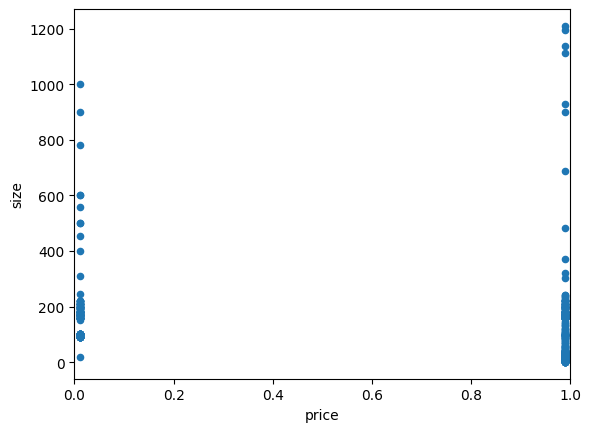

price, size: [0.99, 1209.7979], 
value: 1197.699921, 
z-score: 1.27, 
event mean: 116.54429884143318, 
conditionId: 0xc8f1cf5d4f26e0fd9c8fe89f2a7b3263b902cf14fde7bfccef525753bb492e47, 
title: Will Stephen A. Smith win the 2028 Democratic presidential nomination?, 
 side: BUY, 
 user: 1974kek, 
 transaction hash: 0xf2685c98752fd4534184376bd87b1fe001a60cbb372d1fef4f40f7cd3b6f985e


1

In [24]:


def graph_event(event_id : int, df : pd.DataFrame):
    
    event = df.loc[df.event_id == event_id].copy()

    if event.loc[df.event_id == event_id].empty: 
        #print("\n --------------Empty series---------------- \n")
        return 0

    
    event.plot.scatter(x="price",y="size", **PRICE_PLOT_KWARGS)
    
    plt.show()
    
    max_row = event.loc[event['value'].idxmax()]
    
    print(
        f"price, size: {max_row['price_size_list']}, \n"
        f"value: {max_row['value']}, \n"
        f"z-score: {max_row['z_score']:.2f}, \n"
        f"event mean: {max_row['mean']}, \n"
        f"conditionId: {max_row['conditionId']}, \n"
        f"title: {max_row['title']}, \n",
        f"side: {max_row['side']}, \n",
        f"user: {max_row['name']}, \n",
        f"transaction hash: {max_row['transactionHash']}"
    )

    return 1

graph_event(0, split_df["buys"])


In [25]:
def outliers(df: pd.DataFrame):
    return df.loc[(df.value > 100) & (df.z_score >= 15) & (df.price < .4)].copy()
    
    

In [26]:
all_sell_outliers = outliers(split_df["sells"])
all_buy_outliers = outliers(split_df["buys"])

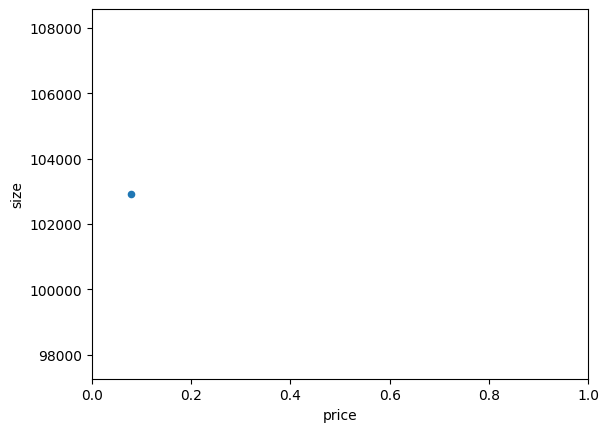

price, size: [0.0790131667430211, 102919.15], 
value: 8131.967959999999, 
z-score: 20.03, 
event mean: 84.47819502502499, 
conditionId: 0x909659c9436228e2be56d5582ba6188166f2f8bf3c596335512c8f2e380d01ec, 
title: Will Kamala Harris win the 2028 Democratic presidential nomination?, 
 side: SELL, 
 user: myanmar666, 
 transaction hash: 0x528dae6b0f90154442c0a0e6a176ef9d0142abc5bac5a8082061d71c2cfdfe98


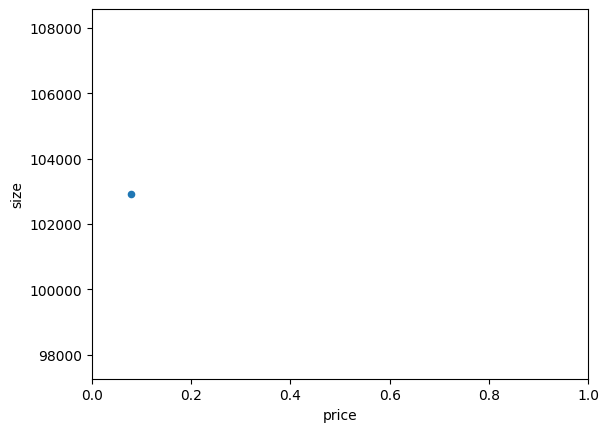

price, size: [0.0790131667430211, 102919.15], 
value: 8131.967959999999, 
z-score: 20.03, 
event mean: 84.47819502502499, 
conditionId: 0x909659c9436228e2be56d5582ba6188166f2f8bf3c596335512c8f2e380d01ec, 
title: Will Kamala Harris win the 2028 Democratic presidential nomination?, 
 side: SELL, 
 user: myanmar666, 
 transaction hash: 0x528dae6b0f90154442c0a0e6a176ef9d0142abc5bac5a8082061d71c2cfdfe98


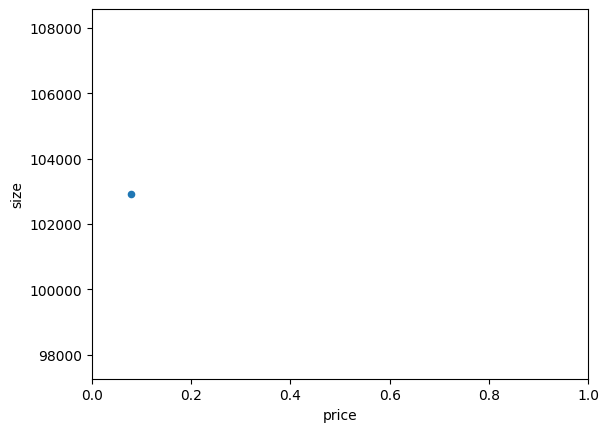

price, size: [0.0790131667430211, 102919.15], 
value: 8131.967959999999, 
z-score: 20.03, 
event mean: 84.47819502502499, 
conditionId: 0x909659c9436228e2be56d5582ba6188166f2f8bf3c596335512c8f2e380d01ec, 
title: Will Kamala Harris win the 2028 Democratic presidential nomination?, 
 side: SELL, 
 user: myanmar666, 
 transaction hash: 0x528dae6b0f90154442c0a0e6a176ef9d0142abc5bac5a8082061d71c2cfdfe98


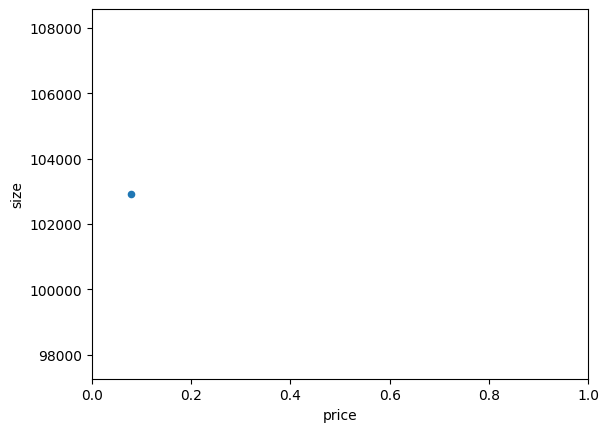

price, size: [0.0790131667430211, 102919.15], 
value: 8131.967959999999, 
z-score: 20.03, 
event mean: 84.47819502502499, 
conditionId: 0x909659c9436228e2be56d5582ba6188166f2f8bf3c596335512c8f2e380d01ec, 
title: Will Kamala Harris win the 2028 Democratic presidential nomination?, 
 side: SELL, 
 user: myanmar666, 
 transaction hash: 0x528dae6b0f90154442c0a0e6a176ef9d0142abc5bac5a8082061d71c2cfdfe98


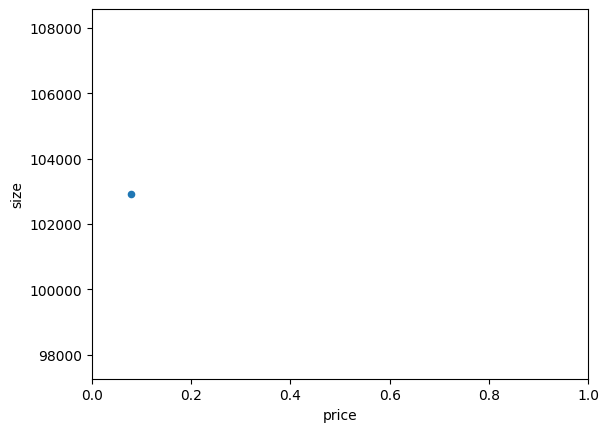

price, size: [0.0790131667430211, 102919.15], 
value: 8131.967959999999, 
z-score: 20.03, 
event mean: 84.47819502502499, 
conditionId: 0x909659c9436228e2be56d5582ba6188166f2f8bf3c596335512c8f2e380d01ec, 
title: Will Kamala Harris win the 2028 Democratic presidential nomination?, 
 side: SELL, 
 user: myanmar666, 
 transaction hash: 0x528dae6b0f90154442c0a0e6a176ef9d0142abc5bac5a8082061d71c2cfdfe98


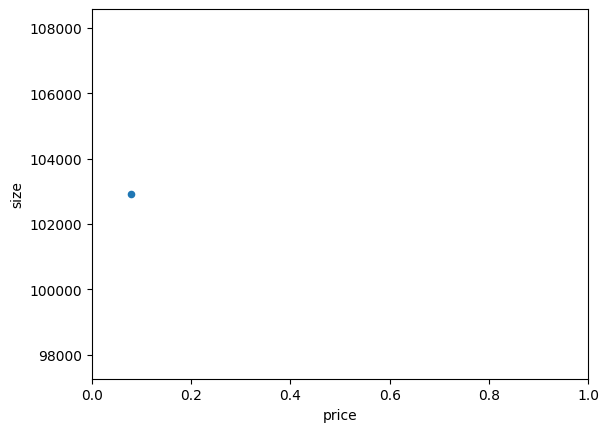

price, size: [0.0790131667430211, 102919.15], 
value: 8131.967959999999, 
z-score: 20.03, 
event mean: 84.47819502502499, 
conditionId: 0x909659c9436228e2be56d5582ba6188166f2f8bf3c596335512c8f2e380d01ec, 
title: Will Kamala Harris win the 2028 Democratic presidential nomination?, 
 side: SELL, 
 user: myanmar666, 
 transaction hash: 0x528dae6b0f90154442c0a0e6a176ef9d0142abc5bac5a8082061d71c2cfdfe98


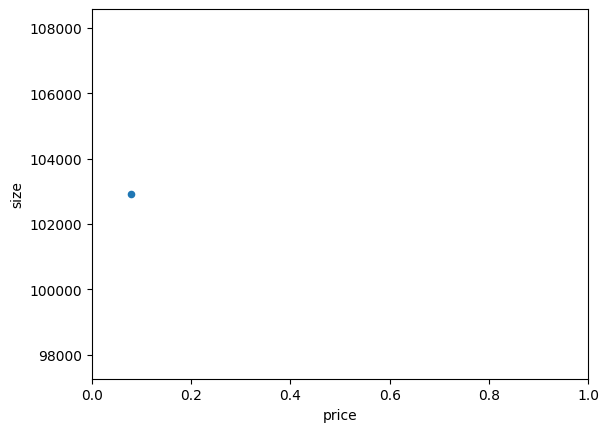

price, size: [0.0790131667430211, 102919.15], 
value: 8131.967959999999, 
z-score: 20.03, 
event mean: 84.47819502502499, 
conditionId: 0x909659c9436228e2be56d5582ba6188166f2f8bf3c596335512c8f2e380d01ec, 
title: Will Kamala Harris win the 2028 Democratic presidential nomination?, 
 side: SELL, 
 user: myanmar666, 
 transaction hash: 0x528dae6b0f90154442c0a0e6a176ef9d0142abc5bac5a8082061d71c2cfdfe98


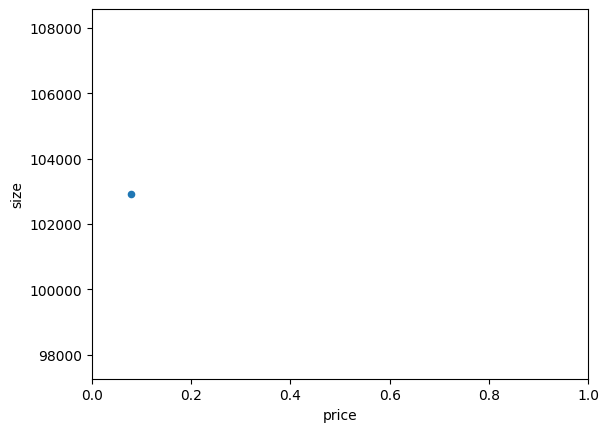

price, size: [0.0790131667430211, 102919.15], 
value: 8131.967959999999, 
z-score: 20.03, 
event mean: 84.47819502502499, 
conditionId: 0x909659c9436228e2be56d5582ba6188166f2f8bf3c596335512c8f2e380d01ec, 
title: Will Kamala Harris win the 2028 Democratic presidential nomination?, 
 side: SELL, 
 user: myanmar666, 
 transaction hash: 0x528dae6b0f90154442c0a0e6a176ef9d0142abc5bac5a8082061d71c2cfdfe98


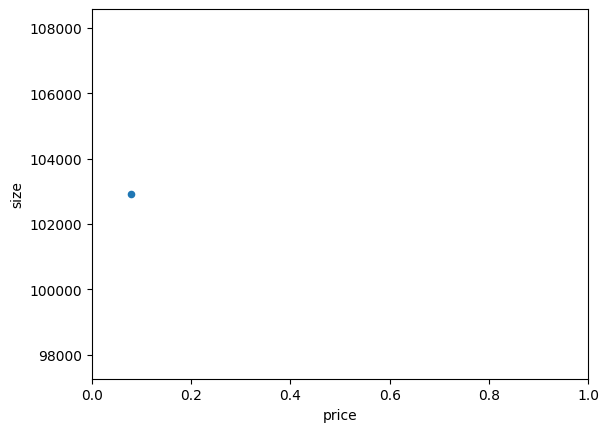

price, size: [0.0790131667430211, 102919.15], 
value: 8131.967959999999, 
z-score: 20.03, 
event mean: 84.47819502502499, 
conditionId: 0x909659c9436228e2be56d5582ba6188166f2f8bf3c596335512c8f2e380d01ec, 
title: Will Kamala Harris win the 2028 Democratic presidential nomination?, 
 side: SELL, 
 user: myanmar666, 
 transaction hash: 0x528dae6b0f90154442c0a0e6a176ef9d0142abc5bac5a8082061d71c2cfdfe98


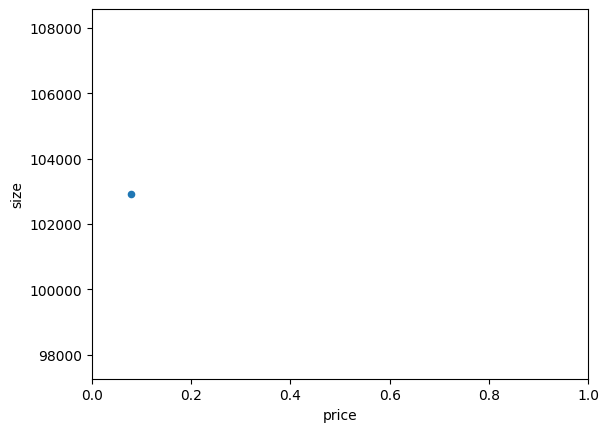

price, size: [0.0790131667430211, 102919.15], 
value: 8131.967959999999, 
z-score: 20.03, 
event mean: 84.47819502502499, 
conditionId: 0x909659c9436228e2be56d5582ba6188166f2f8bf3c596335512c8f2e380d01ec, 
title: Will Kamala Harris win the 2028 Democratic presidential nomination?, 
 side: SELL, 
 user: myanmar666, 
 transaction hash: 0x528dae6b0f90154442c0a0e6a176ef9d0142abc5bac5a8082061d71c2cfdfe98


In [27]:
for i in range(max(df.event_id)):
    #print("Sells VVV")
    graph_event(event_id=i, df = all_sell_outliers)
    #print("Buys VVV")
    graph_event(event_id=i, df = all_buy_outliers)

In [28]:
VALUE_PLOT_KWARGS = {"xlim": (-1,1000)}
def graph_values(df : pd.DataFrame):
    df["value"].hist(bins=150) 
    plt.show()

def graph_values_log(df : pd.DataFrame):S
    df["value"].hist(bins=300, log=True)
    plt.show()

#def log_normal_outputs(df : pd.DataFrame) -> dict:
    
    
    

<class 'pandas.core.frame.DataFrame'>
Index: 5510 entries, 42000 to 1945745
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_id         5510 non-null   int64  
 1   trade_index      5510 non-null   int64  
 2   proxyWallet      5510 non-null   object 
 3   side             5510 non-null   object 
 4   asset            5510 non-null   object 
 5   conditionId      5510 non-null   object 
 6   size             5510 non-null   float64
 7   price            5510 non-null   float64
 8   timestamp        5510 non-null   int64  
 9   title            5510 non-null   object 
 10  slug             5510 non-null   object 
 11  eventSlug        5510 non-null   object 
 12  outcome          5510 non-null   object 
 13  outcomeIndex     5510 non-null   int64  
 14  name             5510 non-null   object 
 15  pseudonym        5510 non-null   object 
 16  transactionHash  5510 non-null   object 
 17  value       

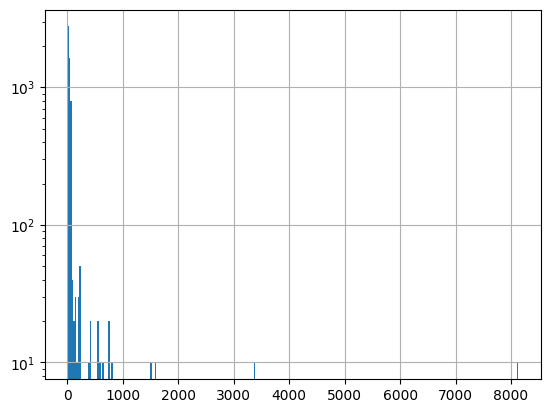

In [37]:
test = split_df["sells"].loc[split_df["sells"].conditionId == "0x909659c9436228e2be56d5582ba6188166f2f8bf3c596335512c8f2e380d01ec"].copy()
#test["value"] = test["value"].round().astype(int)
print(test.info())
graph_values_log(test)